In [1]:
import random
import numpy as np

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

import matplotlib.pyplot as plt
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

from pathlib import Path
import sys
import yaml

# Project root directory
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Shared corpora folder (one level above all repos)
CORPORA_ROOT = PROJECT_ROOT.parents[0] / "corpora"

# Load project configuration
with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)
    

# --- Data
from src.data.data_loader import data_loader
from src.data.remove_group_classes import remove_group_classes
from src.data.preprocessing import preprocessing
from src.data.remove_short_files import remove_short_files
from src.data.equalize_dataframe_signal_lengths import equalize_dataframe_signal_lengths
from src.data.export_dataframe import export_dataframe

# --- Features
from src.features.get_MFBM import get_MFBM
from src.features.extract_voice_features import extract_voice_features
from src.features.analyse_acoustic_feature_distributions import analyse_acoustic_feature_distributions


In [2]:
# --- Load data
# sMEEI corpus, with 4 classes: Control, Edema, Nodules and UVFP
# USP corpus, with 4 classes: Control, Edema, Nodules and Neuro

datasets = {}

for corpus_name in config["data"]["corpora"]:

    df = data_loader(
        dataset_name=corpus_name,
        data_root=str(CORPORA_ROOT)
    )

    datasets[corpus_name] = df
    
    
# Removing unnecessary groups

datasets = remove_group_classes(
    datasets,
    remove_groups=["neuro", "UVFP"]
)

INFO:src.data.data_loader:All signals have same sampling rate: 25000 Hz
INFO:src.data.data_loader:All signals have same sampling rate: 22050 Hz
INFO:src.data.remove_group_classes:mysMEEI: 59 samples removed
INFO:src.data.remove_group_classes:myUSP: 14 samples removed


In [3]:
# Pre-processing: RMS Normalization or 'Peak' normalization
# DC remval
# Eventual silence removal at beginning and end of signals

normalize = config["audio"]["normalize"]
dc_remove = config["audio"]["dc_remove"]
trim_signal = config["audio"]["trim_signal"]

for corpus_name, df in datasets.items():

    datasets[corpus_name] = preprocessing(
        df,
        normalize=normalize,
        dc_remove=dc_remove,
        trim_signal=trim_signal
    )


INFO:src.data.preprocessing:Preprocessing completed (dc_remove=True, trim_signal=True, equal_duration=False, normalize=peak)
INFO:src.data.preprocessing:Preprocessing completed (dc_remove=True, trim_signal=True, equal_duration=False, normalize=peak)


In [4]:
# Equalizing signal duration in both datasets

datasets = equalize_dataframe_signal_lengths(
    datasets,
    preserve=config["audio"]["preserve"],
    #normalize=normalize,
    #dc_remove=dc_remove,
)

INFO:src.data.equalize_dataframe_signal_lengths:Minimum duration per dataset (s): {'mysMEEI': 0.825, 'myUSP': 1.436734693877551}
INFO:src.data.equalize_dataframe_signal_lengths:Global minimum duration (s): 0.825


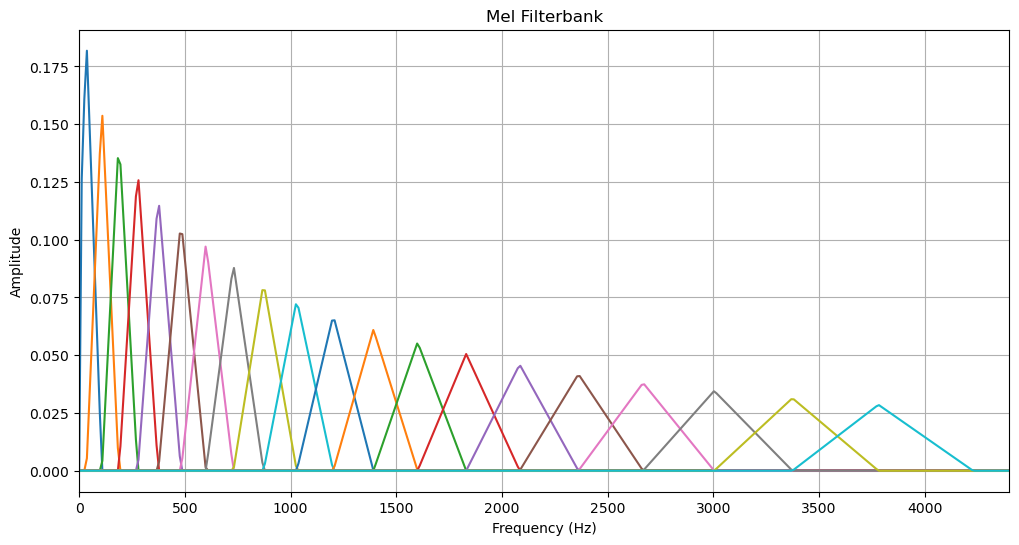

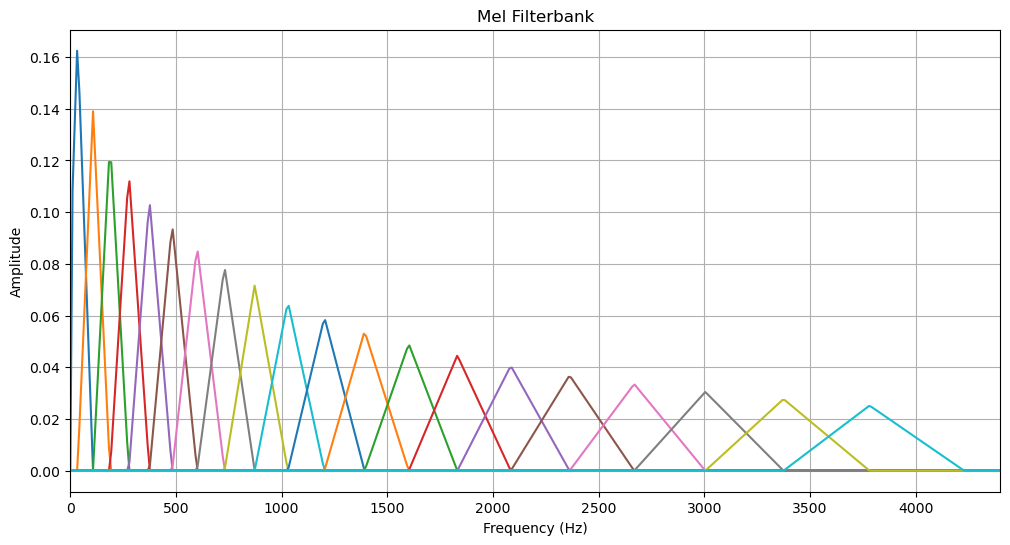

In [5]:
# Getting MFBM values for all signals in both datasets
# Note: the first and last 2 windows values are discarded
# to mitigate eventual signal transition instabilities
# Default: Hann window applied


# --- Parameters
feature_cfg = {
    "tamanho_in": config["features"]["frame_size_ms"],
    "passo_in": config["features"]["hop_size_ms"],
    "n_fft": config["features"]["n_fft"],
    "n_filters": config["features"]["n_filters"],
    "fmax": config["features"]["fmax"],
    "sobrep": config["features"]["overlap"],
    "window_type": config["features"]["window_type"],
    "edge_trim_frames": config["features"]["edge_trim_frames"]
}


for dataset_name, df in datasets.items():

    save_path = (
        PROJECT_ROOT /
        config["results"]["figures_dir"] /
        f"01_{dataset_name}_mel_filterbank.png"
    )


    datasets[dataset_name] = get_MFBM(
        df,
        **feature_cfg,
        print_filters=True,
        save_path=str(save_path)
    )
    

# Note:
# A small amplitude difference can be observed between the Mel filterbank
# outputs of the two datasets.
#
# This difference is caused by the different sampling frequencies, which
# result in different FFT frequency resolutions and therefore different
# numbers of spectral bins contributing to each Mel band.
#
# Since each Mel filter is normalised to unit area (sum of coefficients = 1),
# the filterbank output represents average energy per frequency band rather
# than total accumulated energy. Consequently, the different number of bins
# within each filter bandwidth leads to the observed amplitude differences.

In [6]:
# Extract acoustic features 
# Only Jitter, Shimmer and HNR are used here

acoustic_cfg = config["acoustic_features"]

for dataset_name, df in datasets.items():

    datasets[dataset_name] = extract_voice_features(
        df,
        **acoustic_cfg,
        print_report=True
    )

INFO:src.features.extract_voice_features:Voice feature extraction completed: 92/92 succeeded


       localjitter  localshimmer        hnr
count    92.000000     92.000000  92.000000
mean      0.005283      0.037951  20.407136
std       0.006124      0.032461   5.870490
min       0.000998      0.006325   1.633624
25%       0.002376      0.017451  17.274920
50%       0.003519      0.030249  20.680156
75%       0.005545      0.042382  24.647228
max       0.040231      0.181469  31.566743


INFO:src.features.extract_voice_features:Voice feature extraction completed: 47/47 succeeded


       localjitter  localshimmer        hnr
count    47.000000     47.000000  47.000000
mean      0.005305      0.034028  22.026506
std       0.006243      0.033159   4.900929
min       0.001666      0.009279   9.132578
25%       0.002690      0.016433  19.942046
50%       0.003831      0.022367  22.406360
75%       0.005002      0.034484  25.090960
max       0.041390      0.170338  32.806586


In [7]:
# Analyse the statistical distributions of the acoustic features
# (jitter, shimmer and HNR) to characterize their behaviour and 
# verify they are (not) gaussian.

analyse_acoustic_feature_distributions(datasets)


mysMEEI acoustic feats analysis
                   mean       std  skewness   kurtosis  gaussian_p
feature_name                                                      
localjitter    0.005283  0.006091  3.800042  16.207749    0.000029
localshimmer   0.037951  0.032284  2.417332   6.371606    0.000370
hnr           20.407136  5.838498 -0.628821   0.741458    0.585320

myUSP acoustic feats analysis
                   mean       std  skewness   kurtosis  gaussian_p
feature_name                                                      
localjitter    0.005305  0.006177  4.556446  22.539039    0.000061
localshimmer   0.034028  0.032805  2.657503   6.913263    0.003120
hnr           22.026506  4.848512 -0.460862   0.351966    0.805722


In [8]:
# Standard scaler will be used 
# Applying log-transform to jitter and shimmer distributions
# HNR distribution is already gaussian

def to_log(x):
    # Using 1e-9 as safety for zeros
    return np.log10(100*x + 1e-9)

# USP Jitter and Shimmer
datasets["myUSP"]['localjitter'] = datasets["myUSP"]['localjitter'].apply(to_log)
datasets["myUSP"]['localshimmer'] = datasets["myUSP"]['localshimmer'].apply(to_log)

# sMEEI Jitter and Shimmer
datasets["mysMEEI"]['localjitter'] = datasets["mysMEEI"]['localjitter'].apply(to_log)
datasets["mysMEEI"]['localshimmer'] = datasets["mysMEEI"]['localshimmer'].apply(to_log)

In [9]:
# Verifying the log-transformation turned the 
# jitter and shimmer distributions more gaussian-like


analyse_acoustic_feature_distributions(datasets)

    
"""
Note: log-transform improves normality in both corpora, but the improvement
is stronger in the sMEEI corpus. The USP jitter distribution remains
moderately non-gaussian after transformation (p=0.29), which may reflect
genuine differences in corpus characteristics or recording conditions
"""


mysMEEI acoustic feats analysis
                   mean       std  skewness  kurtosis  gaussian_p
feature_name                                                     
localjitter   -0.416929  0.313364  0.816933  1.100856    0.698431
localshimmer   0.467878  0.300715  0.314670  0.038391    0.786078
hnr           20.407136  5.838498 -0.628821  0.741458    0.585320

myUSP acoustic feats analysis
                   mean       std  skewness  kurtosis  gaussian_p
feature_name                                                     
localjitter   -0.385668  0.256778  1.688646  3.924835    0.270807
localshimmer   0.414489  0.287561  1.023351  0.744299    0.407659
hnr           22.026506  4.848512 -0.460862  0.351966    0.805722


'\nNote: log-transform improves normality in both corpora, but the improvement\nis stronger in the sMEEI corpus. The USP jitter distribution remains\nmoderately non-gaussian after transformation (p=0.29), which may reflect\ngenuine differences in corpus characteristics or recording conditions\n'

In [10]:
# Export dataframes

for dataset_name, df in datasets.items():

    export_dataframe(
        df,
        dataset_name,
        output_root=str(
            PROJECT_ROOT / "data" / "processed"
        ),
        drop_columns=[
            "signal",
            "mfbm",
            "path",
            "fs", 
            'meanf0', 
            'stddevf0'
        ]
    )

INFO:src.data.export_dataframe:Saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\data\processed\mysMEEI.parquet
INFO:src.data.export_dataframe:Saved to: C:\Users\ThinK\Desktop\Github Repos\voice-pathology-mfbm-acoustic-fusion-intracorpus\data\processed\myUSP.parquet
